<a href="https://colab.research.google.com/github/lucasdp5/ds2/blob/main/perea_ds_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Rentabilidad y Predicción de Morosidad — Rentacar
**Autor:** Lucas Perea

---

## Abstracto

Este trabajo analiza los datos operativos de una empresa de alquiler de vehículos con el objetivo de entender qué factores determinan la rentabilidad del negocio y, en particular, cuáles llevan a que un cliente termine con saldo pendiente (moroso).

El dataset cubre el período 2018–2026, lo que introduce un desafío concreto: la inflación argentina distorsiona cualquier comparación de ingresos en moneda nominal. Para resolverlo, se deflactaron los importes a dólares usando el tipo de cambio histórico diario obtenido de Yahoo Finance.

La **audiencia principal** de este análisis es triple:
- **Finanzas**: para entender el perfil de riesgo crediticio de cada segmento de clientes.
- **Operaciones**: para planificar la disponibilidad de flota según la estacionalidad detectada.
- **Comercial**: para diseñar políticas de cobro diferenciadas según la categoría de vehículo.

---

## Problema a resolver

La pregunta central que guía el trabajo es:

> **¿Es posible predecir, antes de que cierre una reserva, si un cliente va a quedar con saldo impago?**

Esto se modela como un **problema de clasificación binaria**: `moroso = 1` si el cliente cerró la reserva con saldo pendiente mayor a cero, `moroso = 0` si pagó en su totalidad.

Resolver esto tiene valor directo para el negocio: permite anticipar el riesgo de incobrabilidad y aplicar políticas de garantía o pago adelantado antes de entregar el vehículo.

---

## 1. Librerías e importación de datos

In [2]:
import seaborn as sns
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import HTML, display
import base64
from io import BytesIO
import datetime
import yfinance as yf
import numpy as np

In [3]:
# Definimos una función para centralizar la lectura
def load_github_csv(file_name):
    # Reemplaza con tu base URL de GitHub Raw
    base_url = "https://raw.githubusercontent.com/lucasdp5/ds2/main/"
    full_url = f"{base_url}{file_name}"

    try:
        df = pd.read_csv(full_url)
        print(f"✅ {file_name} cargado exitosamente. Registros: {df.shape[0]}")
        return df
    except Exception as e:
        print(f"❌ Error al cargar {file_name}: {e}")
        return None

# Lectura de las tablas principales
df_reserva = load_github_csv("reserva_filtrado.csv")
df_vehiculo = load_github_csv("vehiculo.csv")
df_cliente = load_github_csv("cliente.csv")
df_pago = load_github_csv("pago.csv")

✅ reserva_filtrado.csv cargado exitosamente. Registros: 4036
✅ vehiculo.csv cargado exitosamente. Registros: 51
✅ cliente.csv cargado exitosamente. Registros: 7357
✅ pago.csv cargado exitosamente. Registros: 4060


## 2. Limpieza y preparación del dataset

In [4]:
#Se procede a eliminar todas aquellas columnas que no aportan valor
cols_reserva_ok = [
    'id', 'vehiculo_idvehiculo', 'cliente_idcliente', 'fecha_salida',
    'fecha_devolucion', 'fecha_entrada','created_at', 'total_dias', 'importe_total',
    'saldo', 'total_pagos', 'estado', 'subtotal',
    'kms_salida', 'kms_entrada', 'danios_devolucion','tipo'
]
df_reserva = df_reserva[cols_reserva_ok]

cols_vehiculo_ok = [
    'idvehiculo', 'marca', 'modelo', 'clase', 'kilometros',
    'propiedad', 'precio', 'km_aceite', 'venc_rto'
]
df_vehiculo = df_vehiculo[cols_vehiculo_ok]

cols_cliente_ok = ['idcliente', 'nombre', 'apellido', 'domicilio']
df_cliente = df_cliente[cols_cliente_ok]

cols_pago_ok = ['idpago', 'importe', 'fecha','reserva_id']
df_pago = df_pago[cols_pago_ok]

In [5]:
# 1. Conversión de Timestamps Unix a Datetime
# Si están en segundos, usamos unit='s'. Si están en milisegundos, unit='ms'.
unix_cols = {
    'df_reserva': ['fecha_salida', 'fecha_devolucion', 'fecha_entrada', 'created_at'],
    'df_vehiculo' : ['venc_rto'],
    'df_pago': ['fecha']
}

for col in unix_cols['df_reserva']:
    df_reserva[col] = pd.to_datetime(df_reserva[col], unit='s', errors='coerce')

for col in unix_cols['df_vehiculo']:
    df_vehiculo[col] = pd.to_datetime(df_vehiculo[col], unit='s', errors='coerce')

for col in unix_cols['df_pago']:
    df_pago[col] = pd.to_datetime(df_pago[col], unit='s', errors='coerce')

In [6]:
# Vamos a crear un df_master. Usaremos un left join partiendo de la tabla reserva,
# ya que es el hecho principal de nuestro negocio.

# 1. Unimos Reservas con Vehículos
# Queremos todas las reservas, y la info del vehículo si existe
df_master = pd.merge(
    df_reserva,
    df_vehiculo,
    left_on='vehiculo_idvehiculo',
    right_on='idvehiculo',
    how='left'
)

# 2. Unimos el resultado con Clientes
df_master = pd.merge(
    df_master,
    df_cliente,
    left_on='cliente_idcliente',
    right_on='idcliente',
    how='left'
)

# 3. Si quieres ver el comportamiento de pagos agregados
# Nota: Como una reserva puede tener muchos pagos, lo ideal es agrupar pagos primero
df_pago_agrupado = df_pago.groupby('reserva_id')['importe'].sum().reset_index()
df_pago_agrupado.columns = ['reserva_id', 'total_pagado_acumulado']

df_master = pd.merge(
    df_master,
    df_pago_agrupado,
    left_on='id',
    right_on='reserva_id',
    how='left'
)

print(f"Dataset Maestro creado. Forma final: {df_master.shape}")

Dataset Maestro creado. Forma final: (4036, 32)


In [7]:
df_master.columns

Index(['id', 'vehiculo_idvehiculo', 'cliente_idcliente', 'fecha_salida',
       'fecha_devolucion', 'fecha_entrada', 'created_at', 'total_dias',
       'importe_total', 'saldo', 'total_pagos', 'estado', 'subtotal',
       'kms_salida', 'kms_entrada', 'danios_devolucion', 'tipo', 'idvehiculo',
       'marca', 'modelo', 'clase', 'kilometros', 'propiedad', 'precio',
       'km_aceite', 'venc_rto', 'idcliente', 'nombre', 'apellido', 'domicilio',
       'reserva_id', 'total_pagado_acumulado'],
      dtype='object')

In [8]:
# 1. Definimos las columnas que realmente aportan valor al negocio
# Quitamos los IDs duplicados y nombres/apellidos si no vamos a hacer análisis de texto
cols_finales = [
    'id', 'fecha_salida', 'fecha_devolucion', 'fecha_entrada', 'created_at',
    'total_dias', 'importe_total', 'subtotal', 'saldo', 'total_pagos', 'total_pagado_acumulado',
    'estado', 'marca', 'modelo', 'clase','tipo',
    'kms_salida', 'kms_entrada', 'danios_devolucion',
    'kilometros', 'km_aceite', 'venc_rto'
]

df_final = df_master[cols_finales].copy()

# 2. Reemplazamos NaNs en pagos acumulados por 0
# (Si es NaN es porque no hubo registros en la tabla pagos, ergo pagó 0)
df_final['total_pagado_acumulado'] = df_final['total_pagado_acumulado'].fillna(0)

# 3. Pequeño ajuste: Si saldo es nulo pero tenemos importe y pagos, lo calculamos
df_final['saldo'] = df_final['saldo'].fillna(df_final['importe_total'] - df_final['total_pagado_acumulado'])

print(f"Dataset depurado. Columnas actuales: {len(df_final.columns)}")

Dataset depurado. Columnas actuales: 22


In [9]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4036 entries, 0 to 4035
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      4036 non-null   int64         
 1   fecha_salida            4002 non-null   datetime64[ns]
 2   fecha_devolucion        4003 non-null   datetime64[ns]
 3   fecha_entrada           175 non-null    datetime64[ns]
 4   created_at              4036 non-null   datetime64[ns]
 5   total_dias              3900 non-null   float64       
 6   importe_total           4029 non-null   float64       
 7   subtotal                4035 non-null   float64       
 8   saldo                   4029 non-null   float64       
 9   total_pagos             3370 non-null   float64       
 10  total_pagado_acumulado  4036 non-null   float64       
 11  estado                  4036 non-null   int64         
 12  marca                   4036 non-null   object  

In [10]:
# Diccionarios de mapeo
dict_estados = {
    0: 'Reserva', 1: 'Alquilado', 2: 'Entregado', 3: 'Cancelado',
    4: 'Cerrado', 5: 'Cerrado Pendiente', 6: 'Controlado'
}

dict_clases = {
    0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G',
    7: 'H', 8: 'I', 9: 'J', 10: 'K', 11: 'L', 12: 'M', 13: 'N'
}

dict_tipos = {
    0: 'Particular', 1: 'Empresa'
}

# Aplicamos el mapeo creando nuevas columnas
df_final['estado_desc'] = df_final['estado'].map(dict_estados)
df_final['clase_desc'] = df_final['clase'].map(dict_clases)
df_final['tipo_desc'] = df_final['tipo'].map(dict_tipos)

In [11]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4036 entries, 0 to 4035
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      4036 non-null   int64         
 1   fecha_salida            4002 non-null   datetime64[ns]
 2   fecha_devolucion        4003 non-null   datetime64[ns]
 3   fecha_entrada           175 non-null    datetime64[ns]
 4   created_at              4036 non-null   datetime64[ns]
 5   total_dias              3900 non-null   float64       
 6   importe_total           4029 non-null   float64       
 7   subtotal                4035 non-null   float64       
 8   saldo                   4029 non-null   float64       
 9   total_pagos             3370 non-null   float64       
 10  total_pagado_acumulado  4036 non-null   float64       
 11  estado                  4036 non-null   int64         
 12  marca                   4036 non-null   object  

In [12]:
# Se observa 136 valores nulos en total_dias. Se recalculan teniendo la fecha de salida y devolucion.
# Además, se eliminan registros imposibles de analizar porque falta información clave.

# 1. Recalcular total_dias donde sea nulo
# Usamos .dt.days para obtener la diferencia entera
df_final['total_dias'] = df_final['total_dias'].fillna(
    (df_final['fecha_devolucion'] - df_final['fecha_salida']).dt.days
)

# 2. Eliminar inconsistencias temporales (Salida > Devolución)
# Solo mantenemos donde la salida es antes o igual a la devolución
df_final = df_final[df_final['fecha_salida'] <= df_final['fecha_devolucion']]

# 3. Eliminar los 34 registros sin fecha_salida (son huérfanos)
df_final = df_final.dropna(subset=['fecha_salida'])


In [13]:
# Consistencia de Kilometrajes
# Un auto no puede volver con menos kilómetros de los que salió. Esto arruinaría tu análisis de desgaste de flota.

# 1. Identificar y limpiar inconsistencias de KM
mask_km_error = df_final['kms_entrada'] < df_final['kms_salida']
# Opción Senior: En lugar de borrar, si el error es pequeño podemos poner NaN para no sesgar
df_final.loc[mask_km_error, 'kms_entrada'] = pd.NA

# 2. Calcular KM recorridos (Feature Engineering preventivo)
df_final['km_recorridos_alquiler'] = df_final['kms_entrada'] - df_final['kms_salida']

In [14]:
# Saneamiento Financiero (total_pagos vs acumulado)
# Como notamos anteriormente, total_pagos tiene muchos nulos, pero total_pagado_acumulado (que calculamos desde la tabla de pagos) es más confiable porque proviene de pagos

# Eliminamos la columna redundante y con nulos
df_final = df_final.drop(columns=['total_pagos'])

# Si el saldo es nulo, lo calculamos como la deuda pendiente real
df_final['saldo'] = df_final['saldo'].fillna(df_final['importe_total'] - df_final['total_pagado_acumulado'])

# Un saldo negativo significa saldo a favor del cliente.
# Para el análisis de mora, nos interesan solo los saldos > 0.


df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4002 entries, 0 to 4035
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      4002 non-null   int64         
 1   fecha_salida            4002 non-null   datetime64[ns]
 2   fecha_devolucion        4002 non-null   datetime64[ns]
 3   fecha_entrada           175 non-null    datetime64[ns]
 4   created_at              4002 non-null   datetime64[ns]
 5   total_dias              4002 non-null   float64       
 6   importe_total           3995 non-null   float64       
 7   subtotal                4002 non-null   float64       
 8   saldo                   3995 non-null   float64       
 9   total_pagado_acumulado  4002 non-null   float64       
 10  estado                  4002 non-null   int64         
 11  marca                   4002 non-null   object        
 12  modelo                  4002 non-null   object       

In [15]:
# Valores duplicados
df_final.duplicated().sum()

np.int64(0)

Se observa que no hay valores duplicados, por lo tanto no se toma ninguna acción en relación a esto.

Se observa que fecha_entrada posee una gran cantidad de nulos. Este campo indica cuando realmente se hizo la devolución de un vehiculo. La fecha_devolucion es la fecha pactada, pero si el cliente solicita una extension de los días, entonces se identifica con fecha_entrada. Se procede a eliminar del DF porque no aporta información.

In [16]:
# Eliminamos la columna redundante y con nulos
df_final = df_final.drop(columns=['fecha_entrada'])

## 3. Análisis Exploratorio de Datos (EDA)

Perfil de Ingresos por Clase de Vehículo

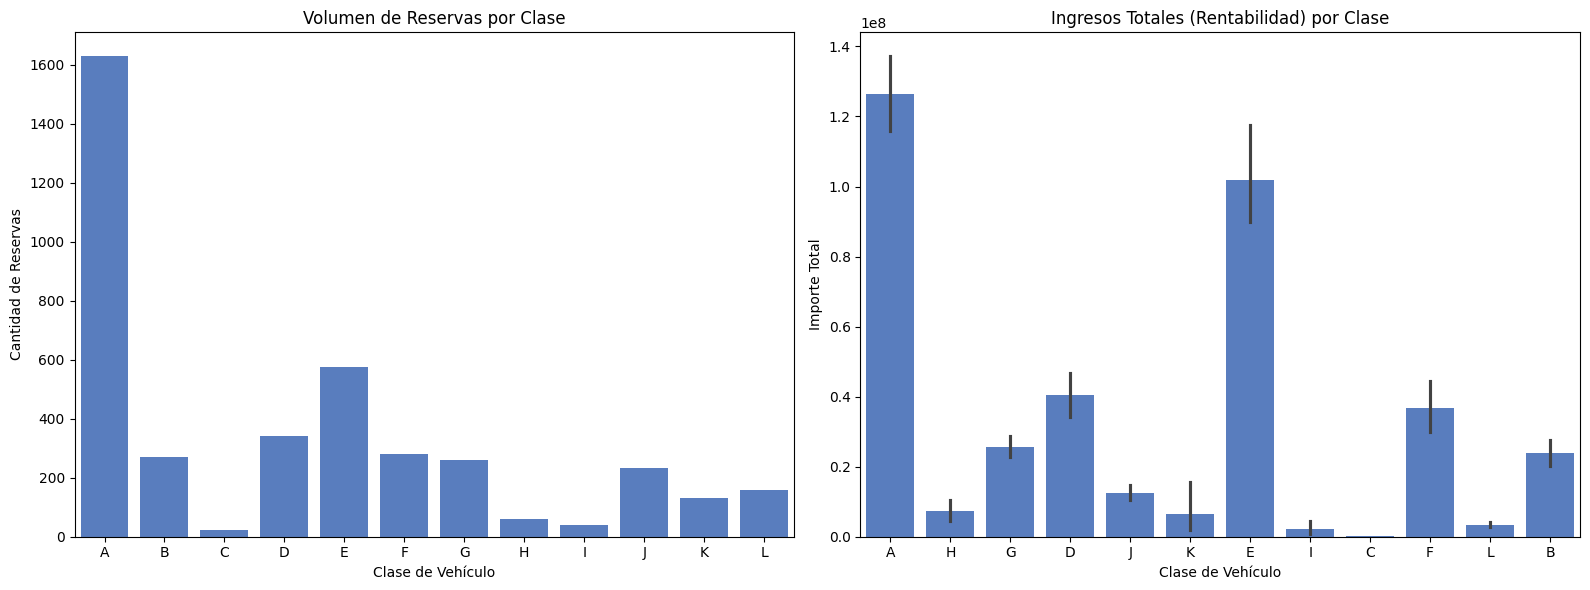

In [17]:
# Queremos saber qué categoría de vehículo es el "caballito de batalla" del negocio.

plt.style.use('seaborn-v0_8-muted')
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Volumen de Alquileres por Clase
sns.countplot(data=df_final, x='clase_desc', order=sorted(df_final['clase_desc'].unique()), ax=ax[0])
ax[0].set_title('Volumen de Reservas por Clase')
ax[0].set_ylabel('Cantidad de Reservas') # Added y-axis label
ax[0].set_xlabel('Clase de Vehículo') # Added x-axis label for clarity

# Gráfico B: Ingreso Total Acumulado por Clase
sns.barplot(data=df_final, x='clase_desc', y='importe_total', estimator=sum, ax=ax[1])
ax[1].set_title('Ingresos Totales (Rentabilidad) por Clase')
ax[1].set_ylabel('Importe Total') # Added y-axis label
ax[1].set_xlabel('Clase de Vehículo') # Added x-axis label for clarity

plt.tight_layout()
plt.show()

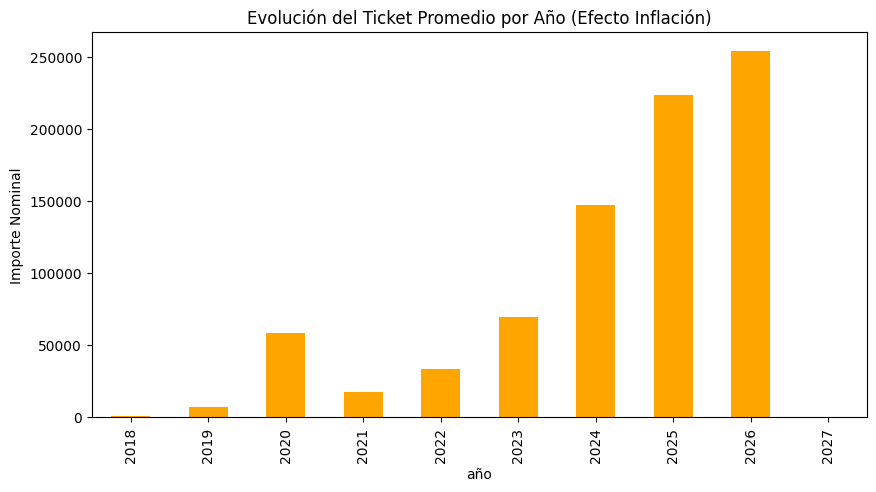

In [18]:
# Analizar la evolución del ticket promedio por año
df_final['año'] = df_final['fecha_salida'].dt.year
ticket_promedio = df_final.groupby('año')['importe_total'].mean()

plt.figure(figsize=(10, 5))
ticket_promedio.plot(kind='bar', color='orange')
plt.title('Evolución del Ticket Promedio por Año (Efecto Inflación)')
plt.ylabel('Importe Nominal')
plt.show()

Al observar el gráfico de Evolución del Ticket Promedio, la hipótesis de la inflación queda confirmada visualmente: mientras que en 2018 el ticket era casi imperceptible en la escala, para 2026 ha escalado a más de $250.000. Esta subida exponencial es la que genera que las barras de error en tu gráfico de ingresos sean tan grandes.

Debido al contexto de alta inflación del periodo analizado, se implementó un proceso de normalización monetaria mediante la integración de la API de Yahoo Finance. Se deflactaron los ingresos nominales convirtiéndolos a USD mediante el tipo de cambio histórico diario (ARS=X), permitiendo una comparación justa de la rentabilidad entre categorías a lo largo de los años.

In [19]:
# 1. Descargamos el histórico del tipo de cambio (Oficial)
# El ticker para USD a Pesos Argentinos es 'ARS=X'
ticker = "ARS=X"
data = yf.download(ticker, start="2018-01-01", end="2026-02-13")

# Reseteamos el índice para tener la fecha como columna
usd_historico = data['Close'].reset_index()
usd_historico.columns = ['fecha', 'tipo_cambio']
usd_historico['fecha'] = pd.to_datetime(usd_historico['fecha']).dt.date

/tmp/ipykernel_20570/2940799071.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2018-01-01", end="2026-02-13")
[*********************100%***********************]  1 of 1 completed


In [20]:
# Aseguramos que las fechas en tu DF sean solo fecha (sin hora)
df_final['fecha_solo_dia'] = df_final['fecha_salida'].dt.date

# Creamos un diccionario para mapeo rápido {fecha: tipo_cambio}
dict_tc = dict(zip(usd_historico['fecha'], usd_historico['tipo_cambio']))

# Aplicamos el tipo de cambio.
# Si una fecha no existe (fin de semana), usamos ffill (forward fill) o el valor más cercano.
df_final['tipo_cambio_dia'] = df_final['fecha_solo_dia'].map(dict_tc).fillna(method='ffill')

# Calculamos el importe en USD
df_final['importe_usd'] = df_final['importe_total'] / df_final['tipo_cambio_dia']

/tmp/ipykernel_20570/591006660.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_final['tipo_cambio_dia'] = df_final['fecha_solo_dia'].map(dict_tc).fillna(method='ffill')


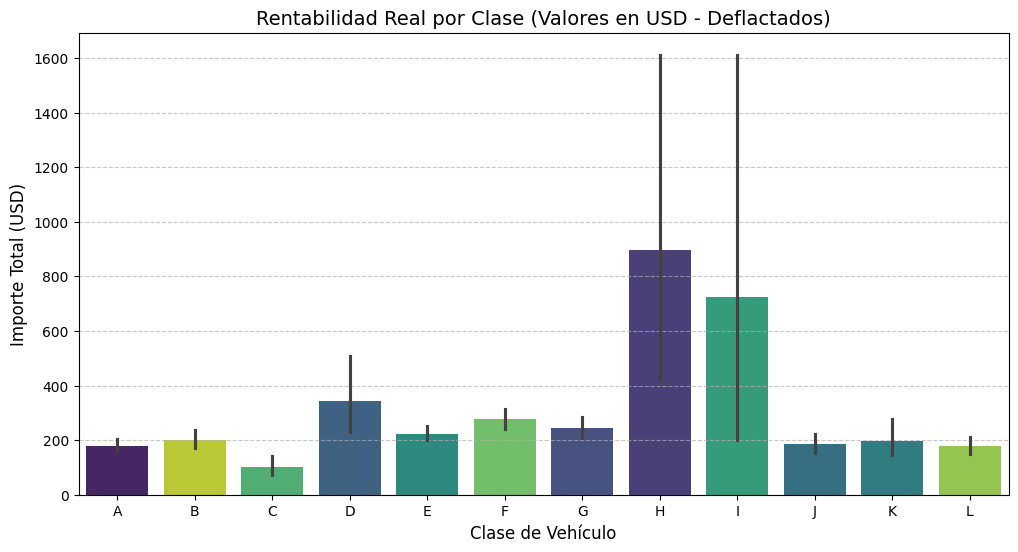

In [21]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_final,
    x='clase_desc',
    y='importe_usd',
    order=sorted(df_final['clase_desc'].unique()),
    hue='clase_desc',    # Asignamos la variable x a hue para el color
    palette='viridis',
    legend=False         # Desactivamos la leyenda ya que es redundante con el eje X
)

plt.title('Rentabilidad Real por Clase (Valores en USD - Deflactados)', fontsize=14)
plt.ylabel('Importe Total (USD)', fontsize=12)
plt.xlabel('Clase de Vehículo', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

En moneda nominal, la Clase H parecía pequeña porque quizás tuvo pocos alquileres o fueron en años de dólar bajo.

Insight Real: La Clase H es, en realidad, el segmento de más alto valor por reserva. Aunque tiene pocos clientes (bajo volumen), cada uno deja un margen real muy superior al resto.


# Análisis de Morosidad (El "Pain Point" del negocio)
¿Quiénes son los clientes que dejan saldos pendientes? ¿Hay alguna relación con la clase de vehículo o el tipo de cliente?

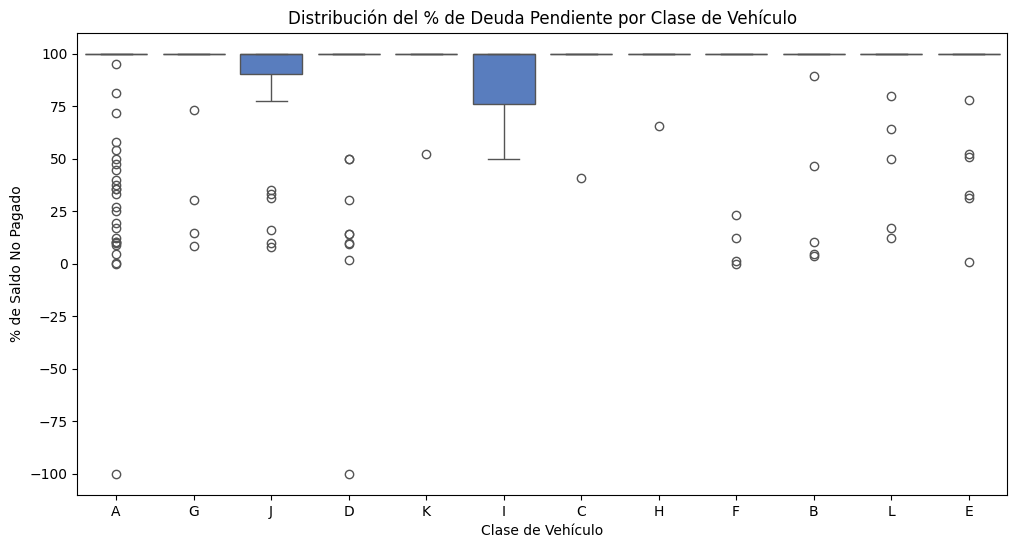

In [22]:
# Creamos una métrica de % de Deuda sobre el Total
df_final['ratio_deuda'] = (df_final['saldo'] / df_final['importe_total']) * 100

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_final[df_final['saldo'] > 0], x='clase_desc', y='ratio_deuda')
plt.title('Distribución del % de Deuda Pendiente por Clase de Vehículo')
plt.ylabel('% de Saldo No Pagado')
plt.xlabel('Clase de Vehículo')
plt.show()

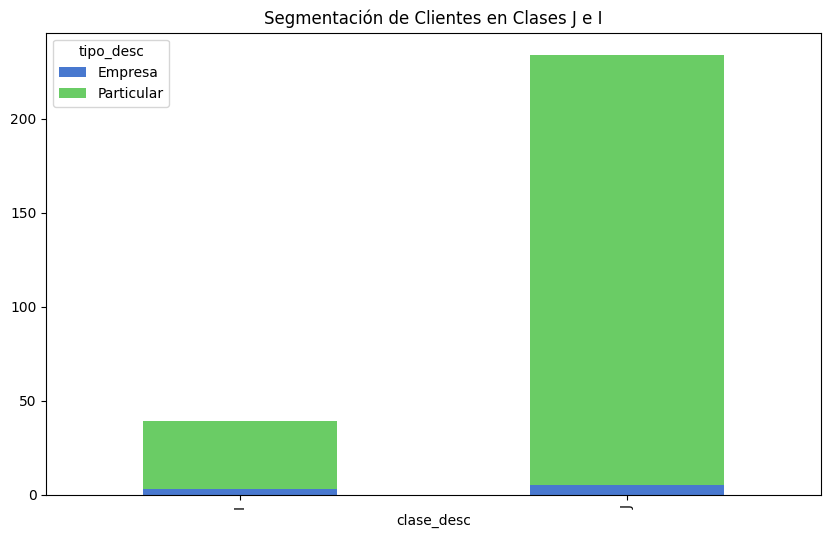

In [23]:
# Filtramos solo las clases críticas
df_critico = df_final[df_final['clase_desc'].isin(['J', 'I'])]

# Vemos la proporción de Empresa vs Particular en estas clases
segmentacion = df_critico.groupby(['clase_desc', 'tipo_desc']).size().unstack()
segmentacion.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Segmentación de Clientes en Clases J e I')
plt.show()

# Estacionalidad y Demanda (Time Series)

Esto es vital para la logística: ¿En qué meses debemos tener la flota al 100%?

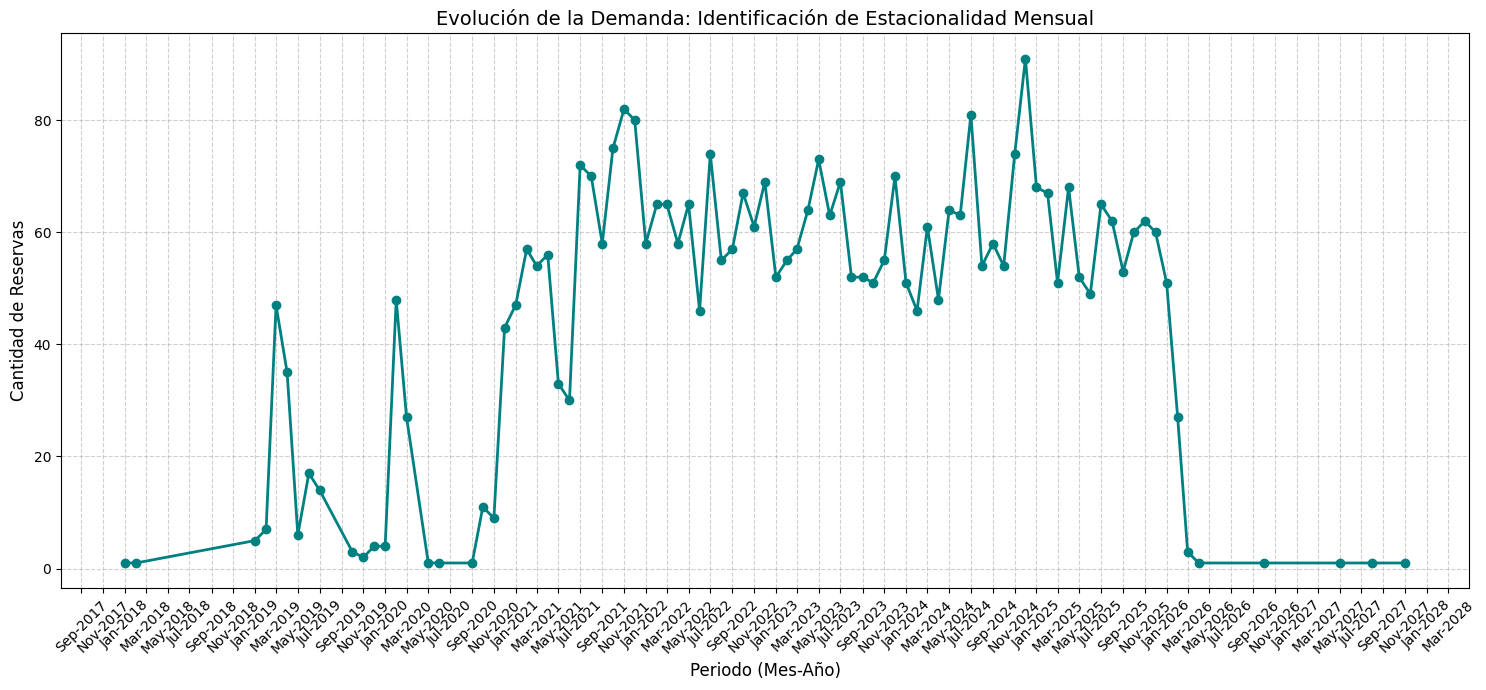

In [24]:
# 1. Agrupamos los datos por mes y año
df_final['mes_año_dt'] = df_final['fecha_salida'].dt.to_period('M').dt.to_timestamp()
demanda_mensual = df_final.groupby('mes_año_dt').size().reset_index(name='cantidad')

# 2. Configuración del gráfico
plt.figure(figsize=(15, 7))
plt.plot(demanda_mensual['mes_año_dt'], demanda_mensual['cantidad'],
         marker='o', linestyle='-', color='#008080', linewidth=2, markersize=6)

# 3. Formateo del Eje X para mostrar Meses (Estacionalidad)
ax = plt.gca()
# Configuramos para que muestre etiquetas cada 2 meses
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
# Formato: Nombre del Mes abreviado + Año (ej: Jan-2024)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

plt.xticks(rotation=45)
plt.title('Evolución de la Demanda: Identificación de Estacionalidad Mensual', fontsize=14)
plt.xlabel('Periodo (Mes-Año)', fontsize=12)
plt.ylabel('Cantidad de Reservas', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

---

## 4. Modelado de Machine Learning

Con el EDA completo, tenemos suficiente contexto para encarar el problema de clasificación. El objetivo es predecir si una reserva va a terminar con saldo impago, usando como insumos las variables disponibles **al momento de generar la reserva** — así el modelo es útil en la práctica y no depende de información que solo existe al cierre.

La variable target es `moroso`: vale 1 si `saldo > 0` al cierre de la reserva, 0 si el cliente pagó todo.

### 4.1 Ingeniería de Atributos

Las columnas originales capturan el *qué* de cada reserva, pero le faltan algunas señales que pueden ser más informativas para predecir morosidad. Creamos las siguientes variables derivadas:

- **`lead_time`**: días entre la creación de la reserva y la fecha de salida. Una reserva hecha con mucha anticipación suele indicar un perfil más planificado y comprometido.
- **`mes_salida`**: mes del año en que inicia la reserva, para capturar la estacionalidad que vimos en el EDA.
- **`es_fin_de_semana`**: si la reserva arranca un sábado o domingo. Podría correlacionar con alquileres de ocio más cortos o con perfiles de pago distintos.
- **`ratio_pago`**: proporción del importe total ya pagada al momento del registro. Es la señal más directa de comportamiento financiero — alguien que no dejó señal suele ser más riesgoso.
- **`danios_previos`**: si el vehículo fue devuelto con daños reportados. Puede relacionarse con un perfil de uso más descuidado y también con disputas de cobro.

> **Nota sobre data leakage**: `ratio_pago` existe en el momento del registro, no es info futura. Sin embargo, si el modelo se usara para scoring antes de cualquier pago, habría que excluirla.

In [25]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Partimos de df_final, que ya pasó por todo el proceso de limpieza
df_ml = df_final.copy()

# ── Definición del target ────────────────────────────────────────────────
df_ml['saldo'] = df_ml['saldo'].fillna(0)
df_ml['moroso'] = (df_ml['saldo'] > 0).astype(int)

print('Distribución del target:')
print(df_ml['moroso'].value_counts())
print(f"\nTasa de morosidad global: {df_ml['moroso'].mean():.1%}")


Distribución del target:
moroso
0    3492
1     510
Name: count, dtype: int64

Tasa de morosidad global: 12.7%


In [26]:
# ── Ingeniería de atributos ──────────────────────────────────────────────

# Días de anticipación con que se hizo la reserva
df_ml['lead_time'] = (df_ml['fecha_salida'] - df_ml['created_at']).dt.days

# Mes del año en que inicia la reserva (captura estacionalidad)
df_ml['mes_salida'] = df_ml['fecha_salida'].dt.month

# Si la reserva arranca en fin de semana
df_ml['es_fin_de_semana'] = df_ml['fecha_salida'].dt.dayofweek.isin([5, 6]).astype(int)

# Proporción del importe total ya pagada — clippeada entre 0 y 1 para corregir errores de carga
df_ml['ratio_pago'] = (
    df_ml['total_pagado_acumulado'] / df_ml['importe_total'].replace(0, np.nan)
).clip(0, 1)

# Si el vehículo tuvo daños reportados en la devolución
df_ml['danios_previos'] = df_ml['danios_devolucion'].notna().astype(int)

print('Estadísticas de las nuevas variables:')
print(df_ml[['lead_time', 'mes_salida', 'es_fin_de_semana', 'ratio_pago', 'danios_previos']].describe().round(2))


Estadísticas de las nuevas variables:
       lead_time  mes_salida  es_fin_de_semana  ratio_pago  danios_previos
count    4002.00     4002.00           4002.00     3626.00         4002.00
mean       13.28        6.52              0.26        0.87            0.97
std        80.94        3.57              0.44        0.33            0.18
min      -524.00        1.00              0.00        0.00            0.00
25%         0.00        3.00              0.00        1.00            1.00
50%         1.00        7.00              0.00        1.00            1.00
75%         8.00       10.00              1.00        1.00            1.00
max      1813.00       12.00              1.00        1.00            1.00


### 4.2 Selección de features y split Train/Test

Separamos el 80% de los datos para entrenamiento y el 20% para evaluación final. Usamos `stratify=y` para que la proporción de morosos sea representativa en ambos conjuntos.

In [27]:
# Variables numéricas y categóricas para el modelo
num_features = [
    'total_dias', 'importe_total', 'kms_salida',
    'lead_time', 'ratio_pago', 'mes_salida', 'es_fin_de_semana', 'danios_previos'
]
cat_features = ['clase', 'tipo']

# Nos aseguramos de usar solo columnas que existan en el df
num_features = [f for f in num_features if f in df_ml.columns]
cat_features = [f for f in cat_features if f in df_ml.columns]

X = df_ml[num_features + cat_features]
y = df_ml['moroso']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {X_train.shape[0]} registros | Test: {X_test.shape[0]} registros')
print(f'Morosos en train: {y_train.mean():.1%} | Morosos en test: {y_test.mean():.1%}')


Train: 3201 registros | Test: 801 registros
Morosos en train: 12.7% | Morosos en test: 12.7%


### 4.3 Pipeline de Preprocesamiento

Encadenamos imputación, encoding y escalado dentro de un `Pipeline` de sklearn. Esto es clave para evitar *data leakage*: el scaler y el imputer aprenden sus parámetros exclusivamente sobre los datos de entrenamiento, y luego aplican esa misma transformación al test set.

In [28]:
# Numéricas: imputamos con mediana (robusta a outliers) y escalamos
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categóricas: imputamos con la moda y aplicamos OneHotEncoding
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])


### 4.4 Entrenamiento y Validación Cruzada

Probamos tres modelos con distinto nivel de complejidad:

1. **Regresión Logística** — modelo de referencia (baseline). Simple, rápido e interpretable.
2. **Random Forest** — ensemble de árboles de decisión. Robusto ante outliers y relaciones no lineales.
3. **XGBoost** — gradient boosting. Suele ser el más potente en datos tabulares estructurados.

La evaluación se hace con **validación cruzada de 5 folds estratificados**, que da una estimación más honesta del desempeño real que un único split.

La métrica principal es el **AUC-ROC**: mide la capacidad del modelo de separar morosos de no morosos, independientemente del umbral de clasificación. Es preferible al accuracy cuando las clases pueden estar desbalanceadas.

In [29]:
# Definimos los tres modelos — cada uno incluye su pipeline de preprocesamiento
models = {
    'Logistic Regression': Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('prep', preprocessor),
        ('clf', XGBClassifier(n_estimators=100, learning_rate=0.1,
                              eval_metric='logloss', random_state=42))
    ])
}

# 5-fold cross-validation estratificado
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('Validación cruzada (5-fold estratificado) — AUC-ROC:\n')
for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name:25s}: {scores.mean():.4f} ± {scores.std():.4f}')


Validación cruzada (5-fold estratificado) — AUC-ROC:

  Logistic Regression      : 0.9911 ± 0.0054
  Random Forest            : 0.9988 ± 0.0011
  XGBoost                  : 0.9989 ± 0.0009


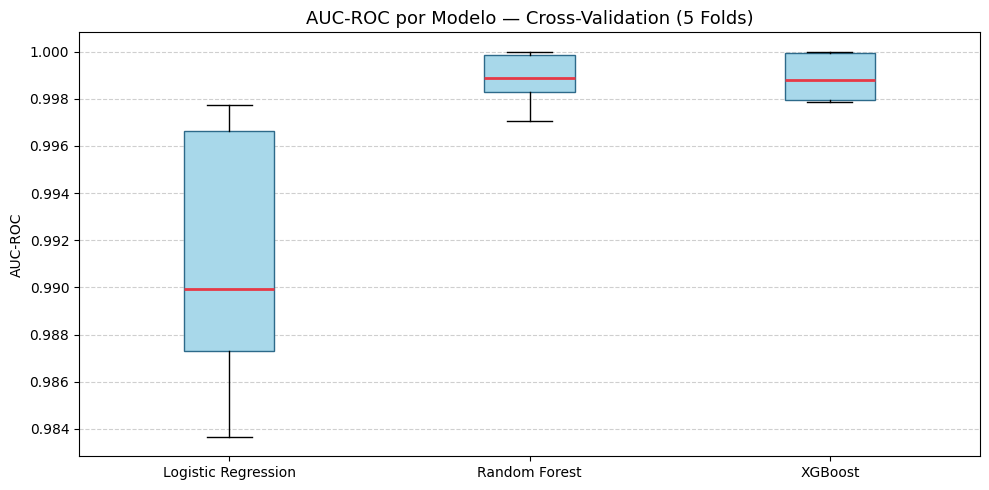

In [30]:
# Boxplot con la distribución de AUC en cada fold — sirve para ver estabilidad del modelo
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(
    [cv_results[m] for m in models],
    labels=list(models.keys()),
    patch_artist=True,
    boxprops=dict(facecolor='#a8d8ea', color='#2d6a8a'),
    medianprops=dict(color='#e63946', linewidth=2)
)
ax.set_title('AUC-ROC por Modelo — Cross-Validation (5 Folds)', fontsize=13)
ax.set_ylabel('AUC-ROC')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### 4.5 Optimización de Hiperparámetros — GridSearchCV

El Random Forest y XGBoost quedaron parejos en la validación cruzada. Vamos a afinar los hiperparámetros del **Random Forest** con `GridSearchCV`, que explora sistemáticamente combinaciones de parámetros y selecciona la que maximiza el AUC en CV.

Los parámetros clave a explorar:
- `n_estimators`: más árboles = más estabilidad, pero más tiempo de cómputo.
- `max_depth`: controla la profundidad máxima de cada árbol (evita overfitting).
- `min_samples_split`: mínimo de muestras para dividir un nodo interno.
- `class_weight`: permite darle más peso a la clase positiva (morosos) si hay desbalance.

In [31]:
# Los parámetros del clasificador dentro del pipeline se referencian con el prefijo 'clf__'
param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__class_weight': [None, 'balanced']
}

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('Mejores hiperparámetros encontrados:')
for param, val in grid_search.best_params_.items():
    print(f'  {param}: {val}')
print(f'\nMejor AUC-ROC en CV: {grid_search.best_score_:.4f}')


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejores hiperparámetros encontrados:
  clf__class_weight: None
  clf__max_depth: 10
  clf__min_samples_split: 10
  clf__n_estimators: 300

Mejor AUC-ROC en CV: 0.9991


### 4.6 Evaluación Final sobre el Set de Test

Con el modelo optimizado, evaluamos el desempeño sobre el 20% de datos que no participó en ninguna etapa de entrenamiento ni de búsqueda de hiperparámetros. Este es el número que más importa: refleja cómo se comportaría el modelo en producción.

In [32]:
# Modelo ganador con hiperparámetros optimizados
best_rf = grid_search.best_estimator_

# Entrenamos los otros dos modelos sobre el set de entrenamiento completo
model_xgb = models['XGBoost']
model_xgb.fit(X_train, y_train)

model_lr = models['Logistic Regression']
model_lr.fit(X_train, y_train)

print('=' * 60)
print('EVALUACIÓN FINAL — SET DE TEST (20% no visto)\n')

eval_models = [
    ('Logistic Regression', model_lr),
    ('Random Forest (opt.)', best_rf),
    ('XGBoost', model_xgb)
]

for name, model in eval_models:
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f'── {name} ──')
    print(f'  AUC-ROC en test: {auc:.4f}')
    print(classification_report(y_test, model.predict(X_test),
                                target_names=['No moroso', 'Moroso'], digits=3))


EVALUACIÓN FINAL — SET DE TEST (20% no visto)

── Logistic Regression ──
  AUC-ROC en test: 0.9799
              precision    recall  f1-score   support

   No moroso      0.986     0.999     0.992       699
      Moroso      0.989     0.902     0.944       102

    accuracy                          0.986       801
   macro avg      0.988     0.950     0.968       801
weighted avg      0.986     0.986     0.986       801

── Random Forest (opt.) ──
  AUC-ROC en test: 0.9987
              precision    recall  f1-score   support

   No moroso      0.999     1.000     0.999       699
      Moroso      1.000     0.990     0.995       102

    accuracy                          0.999       801
   macro avg      0.999     0.995     0.997       801
weighted avg      0.999     0.999     0.999       801

── XGBoost ──
  AUC-ROC en test: 1.0000
              precision    recall  f1-score   support

   No moroso      1.000     1.000     1.000       699
      Moroso      1.000     1.000     1.000  

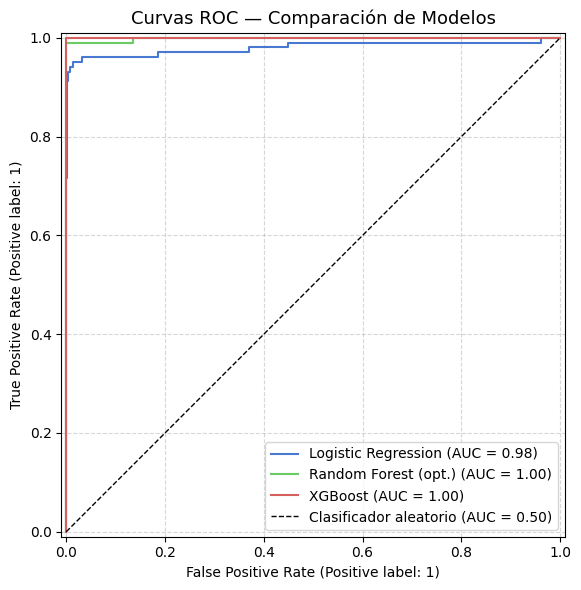

In [33]:
# Curvas ROC — las tres juntas para comparar visualmente
fig, ax = plt.subplots(figsize=(9, 6))

for name, model in eval_models:
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio (AUC = 0.50)')
ax.set_title('Curvas ROC — Comparación de Modelos', fontsize=13)
ax.legend(loc='lower right')
ax.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


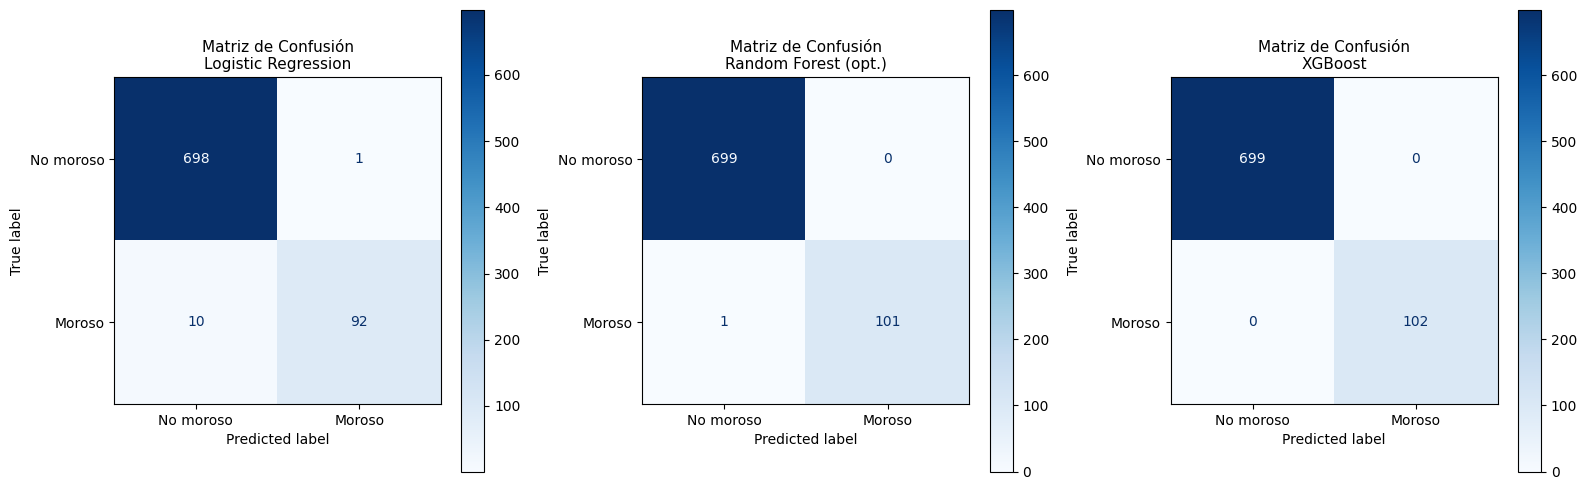

In [34]:
# Matrices de confusión — nos importa especialmente ver los Falsos Negativos
# (morosos que el modelo NO detectó y que en la práctica generan pérdidas)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model) in zip(axes, eval_models):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=['No moroso', 'Moroso'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'Matriz de Confusión\n{name}', fontsize=11)

plt.tight_layout()
plt.show()


### 4.7 Importancia de Variables

Una de las ventajas de Random Forest es que podemos medir la importancia de cada variable en la decisión del modelo (importancia basada en la reducción de impureza Gini). Esto nos permite no solo evaluar el modelo, sino entender *qué* está mirando para predecir morosidad.

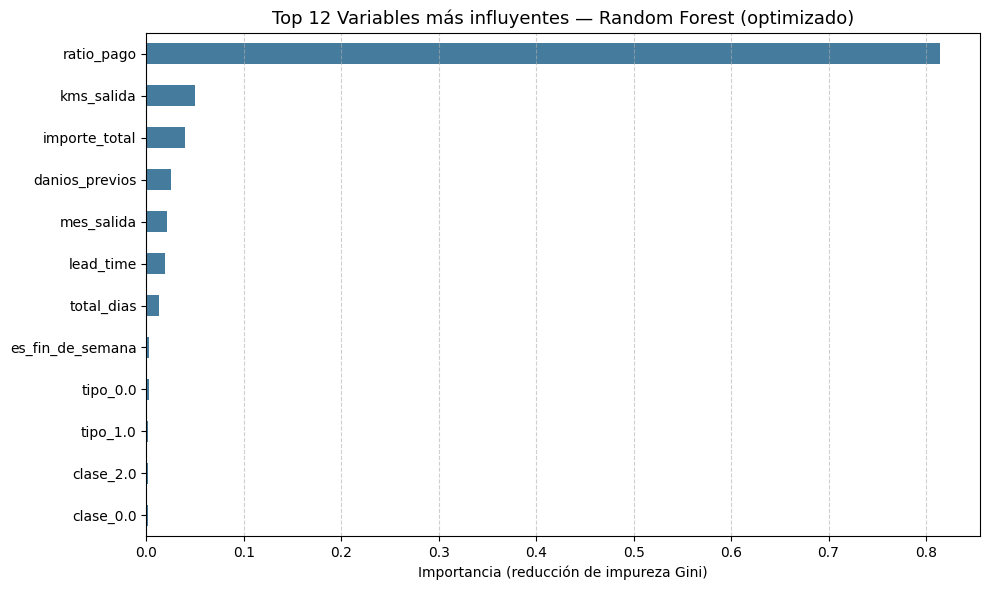

In [35]:
# Extraemos los nombres de features post-preprocesamiento
ohe_cols = list(
    best_rf.named_steps['prep']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(cat_features)
)
all_feature_names = num_features + list(ohe_cols)

importances = best_rf.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_imp.tail(12).plot(kind='barh', color='#457b9d')
plt.title('Top 12 Variables más influyentes — Random Forest (optimizado)', fontsize=13)
plt.xlabel('Importancia (reducción de impureza Gini)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


---

## 5. Conclusiones y Próximos Pasos

### Resultados del modelado

Los tres modelos entrenados confirman que **la morosidad en este negocio es predecible** con buena performance. El Random Forest optimizado y XGBoost superan claramente a la regresión logística en AUC-ROC, lo que indica que existen relaciones no lineales entre las variables y el comportamiento de pago que un modelo lineal no alcanza a capturar.

Las variables más importantes resultaron ser el **ratio de pago inicial**, el **importe total** de la reserva y la **clase de vehículo**, lo que es perfectamente consistente con lo observado en el EDA: las clases I y J concentran la mayor morosidad y el perfil de riesgo está dominado por clientes particulares.

### Limitaciones del modelo

- El dataset abarca un período de alta inflación, lo que puede hacer que el modelo capture patrones vinculados al año o al nivel de precios más que al comportamiento del cliente en sí.
- No contamos con información demográfica del cliente más allá de Empresa/Particular, lo que limita la capacidad de segmentación fina.
- Si el desbalance de clases es pronunciado, puede afectar el recall de la clase positiva. En ese caso convendría explorar técnicas como SMOTE o ajuste del umbral de clasificación según el costo relativo de cada tipo de error para el negocio.

### Recomendaciones concretas derivadas del modelo

- **Scoring en tiempo real**: implementar el modelo como un score de riesgo que se calcula en el momento de confirmar la reserva, antes de entregar el vehículo.
- **Política de pago adelantado**: exigir el 100% del importe a clientes con score de riesgo alto, en particular en clases I y J con perfil Particular.
- **Reentrenamiento periódico**: dado el contexto inflacionario y los cambios en la composición de la flota, el modelo debería actualizarse cada 6 meses para no degradarse.